In [77]:
import numpy as np
from sympy import *
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_lfw_people
init_printing()

# PCA (=Principal Component Analysis)

(The code below might take a while to run, since it loads the LFW dataset, which is quite large. )

In [2]:
lfw_people = fetch_lfw_people(min_faces_per_person=100, resize=0.4)
n_samples, h, w = lfw_people.images.shape
X = lfw_people.data

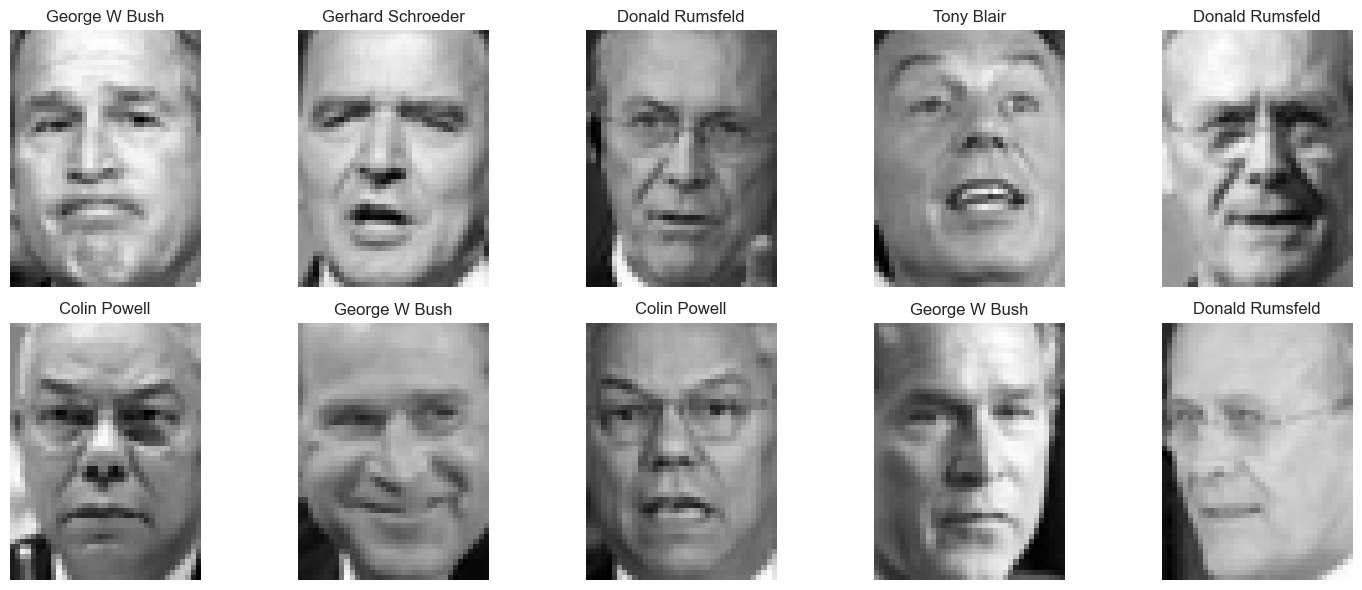

In [3]:
# visualize the first 10 images in the dataset
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(lfw_people.images[i], cmap='gray')
    ax.set_title(lfw_people.target_names[lfw_people.target[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

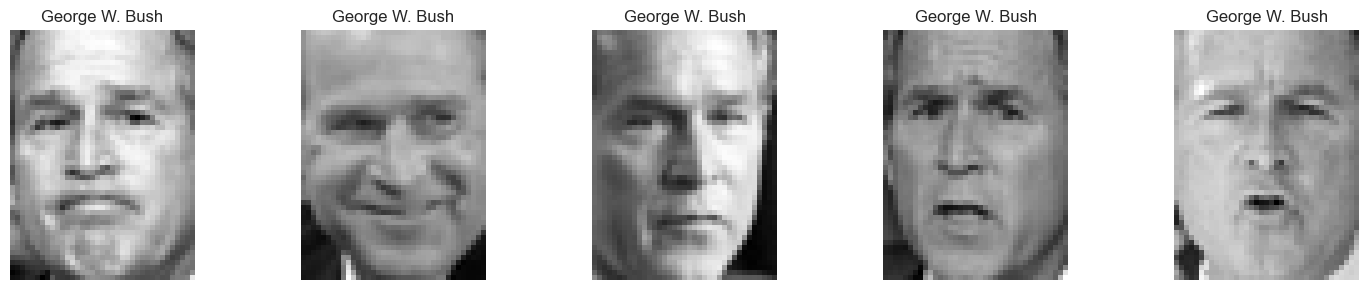

In [10]:
# show 5 images of George W. Bush
bush_indices = np.where(lfw_people.target == np.where(lfw_people.target_names == 'George W Bush')[0][0])[0]
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(lfw_people.images[bush_indices[i]], cmap='gray')
    ax.set_title('George W. Bush')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [59]:
def display_reconstructions(image, flat_image, original_shape, n_components_list):
    n_plots = len(n_components_list)
    cols = 3
    rows = (n_plots + 1 + cols - 1) // cols # +1 for the original image

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4),
                             subplot_kw={'xticks':[], 'yticks':[]})
    axes = axes.flatten()

    for i, n_components in enumerate(n_components_list):
        # 1. Set whiten=False for realistic reconstruction colors
        pca = PCA(n_components=n_components, whiten=False).fit(X)

        components = pca.transform(flat_image)
        reconstructed = pca.inverse_transform(components)

        # Reshape and handle the scale
        img_res = reconstructed.reshape(original_shape)

        # 2. Use 'gray' and let Matplotlib auto-scale the intensity
        axes[i].imshow(img_res, cmap='gray')
        axes[i].set_title(f"{n_components} Components")

    # Display original image in the next available slot
    axes[n_plots].imshow(image, cmap='gray')
    axes[n_plots].set_title("Original Image")

    # Hide any unused subplots
    for j in range(n_plots + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [58]:
def choose_image_and_display_reconstructions(image_index, n_components_list):
    image = lfw_people.images[image_index]
    flat_image = X[image_index].reshape(1, -1)
    display_reconstructions(image, flat_image, (h, w), n_components_list)

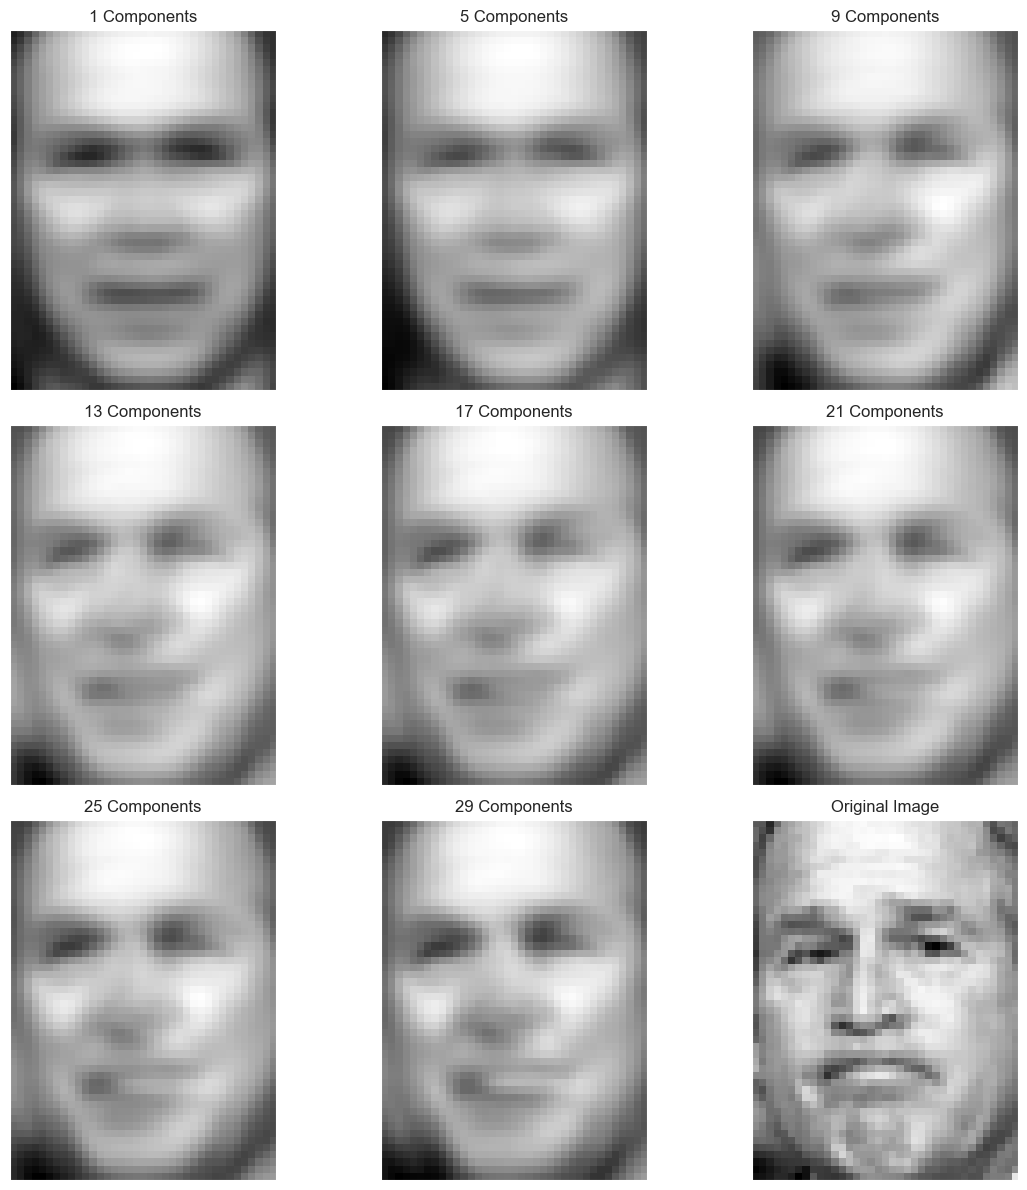

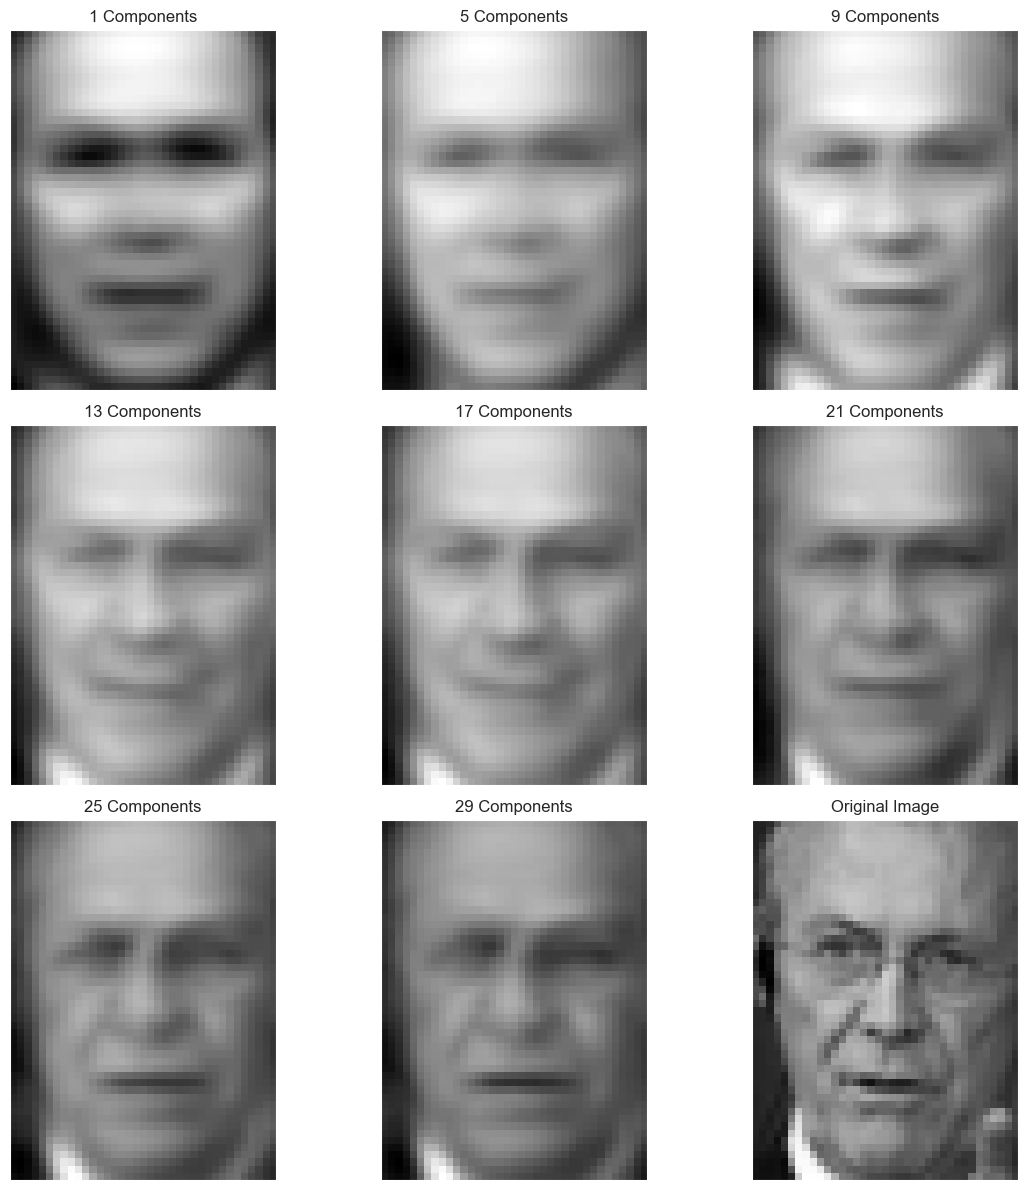

In [60]:
component_list = [1, 5, 9, 13, 17, 21, 25, 29]
choose_image_and_display_reconstructions(0, component_list)
choose_image_and_display_reconstructions(2, component_list)

## Help with linear algebra

In [92]:
X1 = Matrix([1, 2, 1])
X2 = Matrix([4, 2, 13])
X3 = Matrix([7, 8, 1])
X4 = Matrix([8, 4, 5])

In [93]:
# sample mean
N = 4
M = (1/N)*(X1 + X2 + X3 + X4)
M

⎡5.0⎤
⎢   ⎥
⎢4.0⎥
⎢   ⎥
⎣5.0⎦

In [94]:
X1_bar = X1 - M
X2_bar = X2 - M
X3_bar = X3 - M
X4_bar = X4 - M

In [95]:
B = Matrix.hstack(X1_bar, X2_bar, X3_bar, X4_bar)
B

⎡-4.0  -1.0  2.0   3.0⎤
⎢                     ⎥
⎢-2.0  -2.0  4.0    0 ⎥
⎢                     ⎥
⎣-4.0  8.0   -4.0   0 ⎦

In [96]:
S = (1/(N-1)) * (B * B.T)
S

⎡10.0  6.0    0  ⎤
⎢                ⎥
⎢6.0   8.0   -8.0⎥
⎢                ⎥
⎣ 0    -8.0  32.0⎦

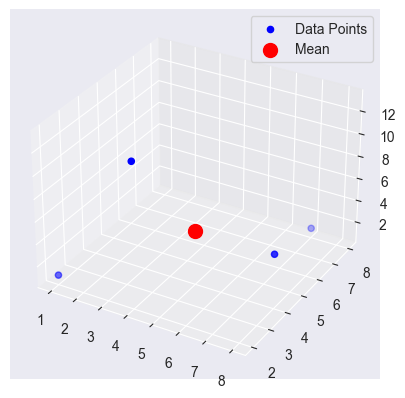

In [97]:
import matplotlib.pyplot as plt
# Convert sympy objects to floats for plotting
X1_f = [float(X1[0]), float(X1[1]), float(X1[2])]
X2_f = [float(X2[0]), float(X2[1]), float(X2[2])]
X3_f = [float(X3[0]), float(X3[1]), float(X3[2])]
X4_f = [float(X4[0]), float(X4[1]), float(X4[2])]
M_f = [float(M[0]), float(M[1]), float(M[2])]

# Plot data points and the mean
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter([X1_f[0], X2_f[0], X3_f[0], X4_f[0]],
           [X1_f[1], X2_f[1], X3_f[1], X4_f[1]],
           [X1_f[2], X2_f[2], X3_f[2], X4_f[2]], color='b', label='Data Points')
ax.scatter([M_f[0]], [M_f[1]], [M_f[2]], color='r', s=100, label='Mean')
ax.legend()
plt.show()

In [98]:
eigenvectors = S.eigenvects()
eigenvectors

⎡⎛                     ⎡⎡-0.568610032582468⎤⎤⎞  ⎛                    ⎡⎡-0.8192 ↪
⎢⎜                     ⎢⎢                  ⎥⎥⎟  ⎜                    ⎢⎢        ↪
⎢⎜1.60571114275905, 1, ⎢⎢0.795512810103738 ⎥⎥⎟, ⎜13.842964240721, 1, ⎢⎢-0.5247 ↪
⎢⎜                     ⎢⎢                  ⎥⎥⎟  ⎜                    ⎢⎢        ↪
⎣⎝                     ⎣⎣0.209384812742995 ⎦⎦⎠  ⎝                    ⎣⎣-0.2311 ↪

↪ 67496123635⎤⎤⎞  ⎛                   ⎡⎡0.0740499874535684⎤⎤⎞⎤
↪            ⎥⎥⎟  ⎜                   ⎢⎢                  ⎥⎥⎟⎥
↪ 35948531356⎥⎥⎟, ⎜34.55132461652, 1, ⎢⎢0.303004213303632 ⎥⎥⎟⎥
↪            ⎥⎥⎟  ⎜                   ⎢⎢                  ⎥⎥⎟⎥
↪ 98949206538⎦⎦⎠  ⎝                   ⎣⎣-0.950107912859573⎦⎦⎠⎦

In [99]:
# the largest eigenvalue is the one that corresponds to the principal component, so we want to order them from largest to smallest
l1 = eigenvectors[2][0]
l2 = eigenvectors[1][0]
l3 = eigenvectors[0][0]
l1, l2, l3

In [106]:
trace = l1 + l2 + l3
trace

In [100]:
v1 = eigenvectors[2][2][0]
v2 = eigenvectors[1][2][0]
v3 = eigenvectors[0][2][0]
v1, v2, v3

⎛⎡0.0740499874535684⎤  ⎡-0.819267496123635⎤  ⎡-0.568610032582468⎤⎞
⎜⎢                  ⎥  ⎢                  ⎥  ⎢                  ⎥⎟
⎜⎢0.303004213303632 ⎥, ⎢-0.524735948531356⎥, ⎢0.795512810103738 ⎥⎟
⎜⎢                  ⎥  ⎢                  ⎥  ⎢                  ⎥⎟
⎝⎣-0.950107912859573⎦  ⎣-0.231198949206538⎦  ⎣0.209384812742995 ⎦⎠

In [101]:
l1 = l1.round(2)
l2 = l2.round(2)
l3 = l3.round(2)

D = Matrix([[l1, 0, 0], [0, l2, 0], [0, 0, l3]])
D

⎡34.55    0     0  ⎤
⎢                  ⎥
⎢  0    13.84   0  ⎥
⎢                  ⎥
⎣  0      0    1.61⎦

In [102]:
P = Matrix.hstack(v1, v2, v3)
P

⎡0.0740499874535684  -0.819267496123635  -0.568610032582468⎤
⎢                                                          ⎥
⎢0.303004213303632   -0.524735948531356  0.795512810103738 ⎥
⎢                                                          ⎥
⎣-0.950107912859573  -0.231198949206538  0.209384812742995 ⎦

In [103]:
x1, x2, x3 = symbols('x1 x2 x3')
# approximate v1, v2, v3 as numerical vectors
v1 = v1.evalf(2)
v2 = v2.evalf(2)
v3 = v3.evalf(2)

PC1 = v1[0]*x1 + v1[1]*x2 + v1[2]*x3
PC2 = v2[0]*x1 + v2[1]*x2 + v2[2]*x3
PC3 = v3[0]*x1 + v3[1]*x2 + v3[2]*x3
PC1, PC2, PC3

In [105]:
explained1 = ((l1 / trace)*100).round(1)
explained2 = ((l2 / trace)*100).round(1)
explained3 = ((l3 / trace)*100).round(1)
explained1, explained2, explained3

## Choosing the number of components

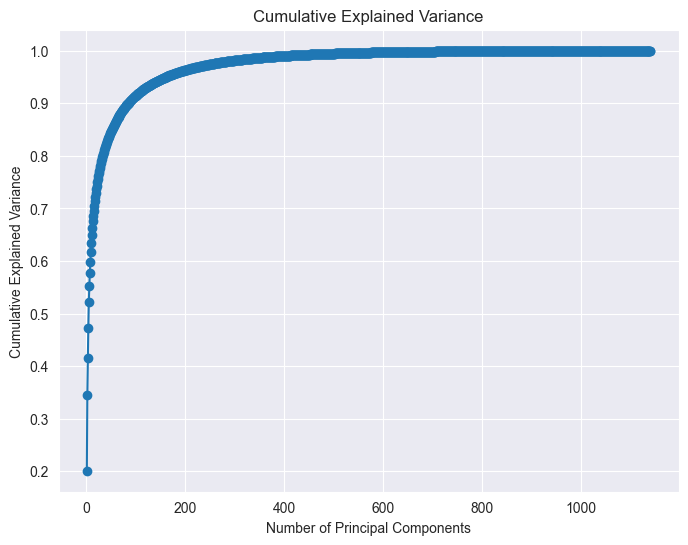

In [113]:
def visualize_elbow(X_data, title="Cumulative Explained Variance"):
    pca = PCA().fit(X_data)
    cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title(title)
    plt.grid(True)
    plt.show()

# Visualize the elbow to find the appropriate number of components
visualize_elbow(X)

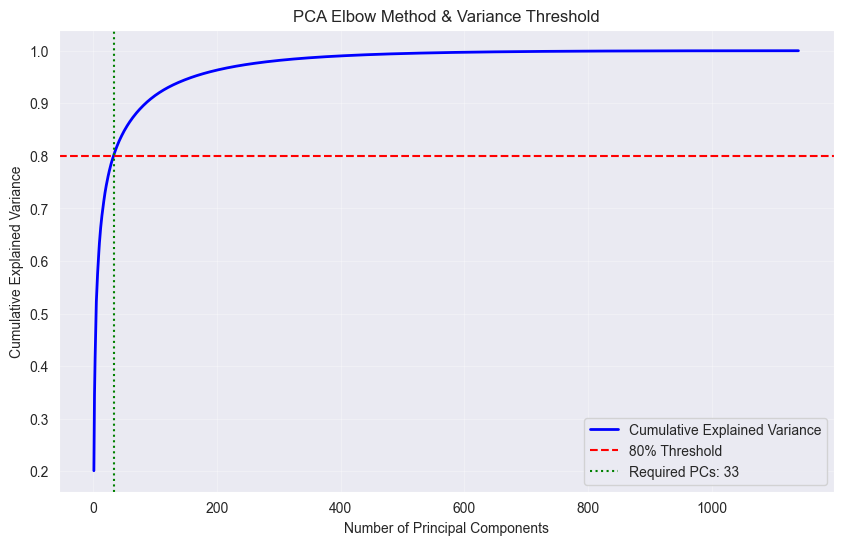

To explain 80.09% of the variance, you need 33 components.


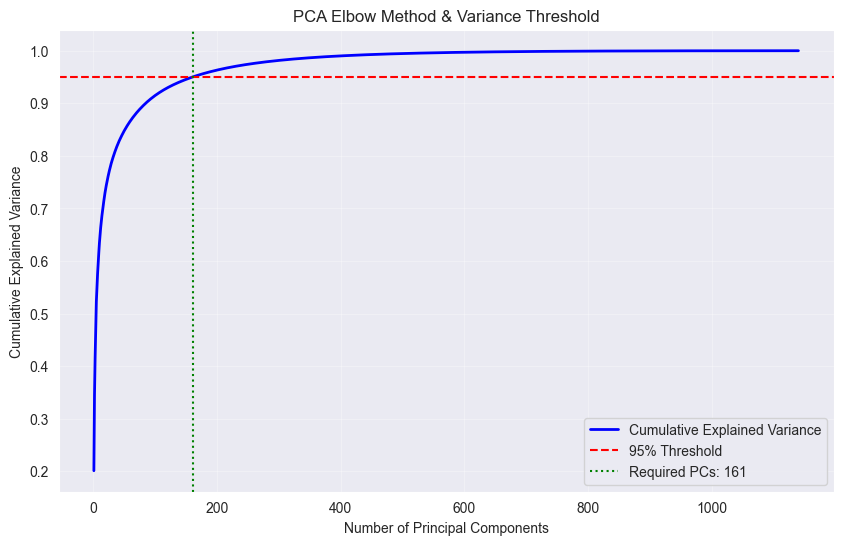

To explain 95.02% of the variance, you need 161 components.


In [118]:
def find_pca_thresholds(X_data, threshold=0.80):
    # 1. Fit PCA on the full dataset to see the total variance distribution
    # We use min(n_samples, n_features) as the maximum possible components
    pca = PCA().fit(X_data)

    # Calculate cumulative variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    # 2. Find the exact number of components for the threshold (e.g., 80%)
    # We add 1 because index is 0-based
    n_components_threshold = np.argmax(cumulative_variance >= threshold) + 1
    variance_at_threshold = cumulative_variance[n_components_threshold - 1]

    # 3. Visualization (Elbow Method)
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
             color='blue', lw=2, label='Cumulative Explained Variance')

    # Add a horizontal line for the threshold
    plt.axhline(y=threshold, color='r', linestyle='--',
                label=f'{int(threshold*100)}% Threshold')

    # Add a vertical line for the resulting n_components
    plt.axvline(x=n_components_threshold, color='g', linestyle=':',
                label=f'Required PCs: {n_components_threshold}')

    plt.title('PCA Elbow Method & Variance Threshold')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"To explain {variance_at_threshold:.2%} of the variance, you need {n_components_threshold} components.")
    return n_components_threshold

# Execute
n_80 = find_pca_thresholds(X, threshold=0.80)
n_95 = find_pca_thresholds(X, threshold=0.95)